# Predicting Daily Rainfall in Melbourne Using Machine Learning
## A Temporal Validation and Model Comparison Study

**Portfolio notebook — Python / Machine Learning / Predictive Analytics**

### Research question
> **How effectively can meteorological observations available on day \(t\) predict rainfall on day \(t+1\) in the Melbourne metropolitan area, and how do alternative machine-learning classifiers perform under temporally realistic out-of-sample evaluation?**

### Provenance and research integrity
This notebook develops an earlier rainfall-classification exercise from the **IBM Machine Learning Certificate** into a more rigorous, research-oriented machine-learning study. The original work established the technical foundation: pandas-based preprocessing, `ColumnTransformer`, `Pipeline`, `GridSearchCV`, Random Forest and Logistic Regression, classification diagnostics, and feature-importance analysis.\
All methodological extensions in the main analysis are part of the portfolio redevelopment and should be interpreted as subsequent independent work.

**Important:** this is a predictive modeling study, not a causal analysis. Feature importance indicates predictive reliance, not causal effect.

## 1. Reproducibility and analytical design

A forecasting evaluation should approximate deployment: information from the future must not influence model fitting, imputation, scaling, hyperparameter selection, threshold choice, or final evaluation.

The notebook therefore uses three chronological layers:

1. **Model-development period:** observations before 2016.
2. **Validation period:** 2016, used for model comparison and threshold selection.
3. **Final test period:** 2017, held untouched until final evaluation.

Within the model-development period, hyperparameters are selected using expanding-window folds in which every validation year is strictly later than its corresponding training years.

This design follows the principle behind scikit-learn's `TimeSeriesSplit`: ordinary cross-validation is inappropriate for time-ordered data when it would train on future observations and evaluate on the past.

### Key references
- Australian Bureau of Meteorology, *About rainfall data*: https://www.bom.gov.au/climate/cdo/about/about-rain-data.shtml
- scikit-learn, *TimeSeriesSplit*: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- scikit-learn, *Permutation feature importance*: https://scikit-learn.org/stable/modules/permutation_importance.html
- scikit-learn, *Probability calibration*: https://scikit-learn.org/stable/modules/calibration.html

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn_version)
print("Platform:", platform.platform())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-b25i98uj because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Python: 3.13.5
pandas: 2.2.3
scikit-learn: 1.8.0
Platform: Linux-6.18.35-x86_64-with-glibc2.41


## 2. Data source and forecasting target

The source dataset contains daily weather observations from Australian weather stations from approximately 2008–2017. The target `RainTomorrow` indicates whether the following day recorded at least approximately 1 mm of rain in the dataset definition.

Some variables:

- predictors at date \(t\): weather observations available for that row;
- target: `RainTomorrow`, corresponding to rainfall on day \(t+1\).

The study focuses on three Melbourne-area stations:
- `Melbourne`
- `MelbourneAirport`
- `Watsonia`

In [2]:
# import data

data_path = Path("/mnt/data/weatherAUS_2.csv")

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"

if data_path is not None:
    raw = pd.read_csv(data_path)
    print(f"Loaded local dataset: {data_path}")
else:
    raw = pd.read_csv(DATA_URL)
    print("Loaded dataset from IBM certificate data host.")

print("Raw shape:", raw.shape)
raw.head()

Loaded local dataset: /mnt/data/weatherAUS_2.csv
Raw shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
# Basic data information
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_missing": raw.notna().sum(),
    "missing": raw.isna().sum(),
    "missing_pct": (100 * raw.isna().mean()).round(2),
    "n_unique": raw.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

audit

,dtype,non_missing,missing,missing_pct,n_unique
Sunshine,float64,75625,69835,48.01,145
Evaporation,float64,82670,62790,43.17,358
Cloud3pm,float64,86102,59358,40.81,10
Cloud9am,float64,89572,55888,38.42,10
Pressure9am,float64,130395,15065,10.36,546
Pressure3pm,float64,130432,15028,10.33,549
WindDir9am,object,134894,10566,7.26,16
WindGustDir,object,135134,10326,7.10,16
WindGustSpeed,float64,135197,10263,7.06,67
Humidity3pm,float64,140953,4507,3.10,101


### Missing-data strategy

The original IBM exercise used `df.dropna()`, reducing 145,460 raw rows to 56,420 complete cases. That is convenient pedagogically but discards a large majority of the original records and can change the composition of the analytical sample.

Here in my improved notebook, only rows without an observed target (and unusable dates) are removed. Numerical predictors are median-imputed and categorical predictors are mode-imputed **inside each fitted pipeline**, so imputation parameters are learned from training data only.

In [4]:
df = raw.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

metro_locations = ["Melbourne", "MelbourneAirport", "Watsonia"]
df = df[df["Location"].isin(metro_locations)].copy()

# A supervised-learning row requires an observed date and observed outcome.
df = df.dropna(subset=["Date", "RainTomorrow"]).sort_values(["Date", "Location"]).reset_index(drop=True)

print("Melbourne-metro analytical rows:", len(df))
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("\nRows by station:")
display(df["Location"].value_counts().rename("rows").to_frame())

print("\nTarget distribution:")
display(df["RainTomorrow"].value_counts().rename("count").to_frame())
print("Rain prevalence: {:.2%}".format((df["RainTomorrow"] == "Yes").mean()))

Melbourne-metro analytical rows: 8443
Date range: 2008-07-01 to 2017-06-25

Rows by station:


,rows
Location,
MelbourneAirport,3009
Watsonia,2999
Melbourne,2435



Target distribution:


,count
RainTomorrow,
No,6416
Yes,2027


Rain prevalence: 24.01%


## 3. Exploratory data analysis

The EDA focuses on:
1. class imbalance;
2. missingness;
3. temporal prevalence of rainfall;
4. station heterogeneity;
5. seasonality.


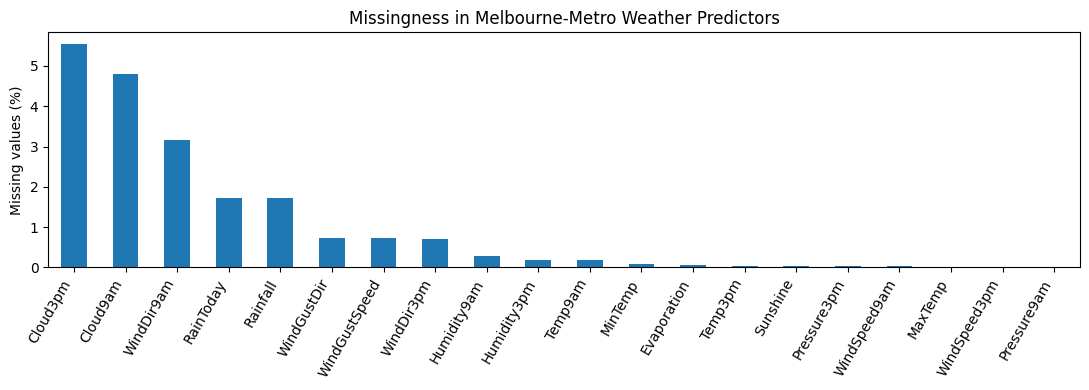

In [5]:
# Missingness profile in the Melbourne subset
missing = (100 * df.isna().mean()).sort_values(ascending=False)
missing = missing[missing > 0]

ax = missing.plot(kind="bar", figsize=(11, 4))
ax.set_title("Missingness in Melbourne-Metro Weather Predictors")
ax.set_ylabel("Missing values (%)")
ax.set_xlabel("")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

,observations,rain_rate
Year,,
2008,184,21.20
2009,1095,21.37
2010,1094,26.51
2011,951,26.08
2012,930,27.63
2013,939,24.49
2014,1018,20.53
2015,734,20.57
2016,972,27.88


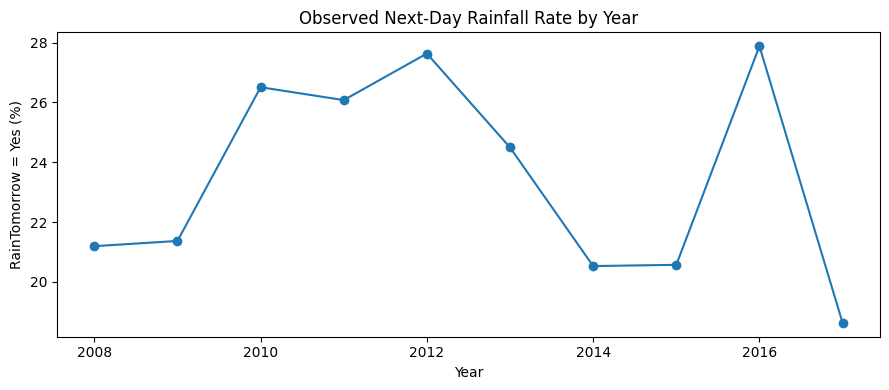

In [6]:
# Rain prevalence by calendar year
yearly = (
    df.assign(Year=df["Date"].dt.year, Rain=(df["RainTomorrow"] == "Yes").astype(int))
      .groupby("Year")
      .agg(observations=("Rain", "size"), rain_rate=("Rain", "mean"))
)
yearly["rain_rate"] *= 100

display(yearly.round(2))

ax = yearly["rain_rate"].plot(marker="o", figsize=(9, 4))
ax.set_title("Observed Next-Day Rainfall Rate by Year")
ax.set_ylabel("RainTomorrow = Yes (%)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

,observations,rain_rate_pct
Season,,
Summer,1995,16.59
Autumn,2178,22.04
Winter,2163,29.31
Spring,2107,27.62


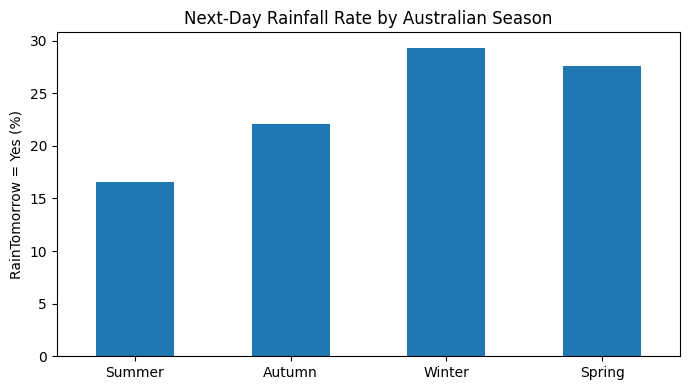

In [7]:
# seasonality
def australian_season(month):
    if month in (12, 1, 2):
        return "Summer"
    if month in (3, 4, 5):
        return "Autumn"
    if month in (6, 7, 8):
        return "Winter"
    return "Spring"

df["Season"] = df["Date"].dt.month.map(australian_season)

season_order = ["Summer", "Autumn", "Winter", "Spring"]
season_rate = (
    df.assign(Rain=(df["RainTomorrow"] == "Yes").astype(int))
      .groupby("Season")["Rain"].agg(["count", "mean"])
      .reindex(season_order)
)
season_rate["mean"] *= 100
season_rate.columns = ["observations", "rain_rate_pct"]
display(season_rate.round(2))

ax = season_rate["rain_rate_pct"].plot(kind="bar", figsize=(7, 4))
ax.set_title("Next-Day Rainfall Rate by Australian Season")
ax.set_ylabel("RainTomorrow = Yes (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# station heterogeneity
station_rate = (
    df.assign(Rain=(df["RainTomorrow"] == "Yes").astype(int))
      .groupby("Location")["Rain"].agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)
station_rate["mean"] *= 100
station_rate.columns = ["observations", "rain_rate_pct"]
station_rate.round(2)

,observations,rain_rate_pct
Location,,
Melbourne,2435,26.12
Watsonia,2999,24.61
MelbourneAirport,3009,21.70


## 4. Feature engineering

The raw date will not be supplied directly to the classifier. Instead, the model receives:
- `Year` only for partitioning and diagnostics, not as a predictor;
- cyclical day-of-year features (`sin` and `cos`) to represent annual periodicity smoothly;
- the interpretable categorical `Season` feature retained from the original project.

Using both cyclical features and season labels allows the models to capture gradual annual changes while preserving an easily interpretable seasonal grouping for downstream error analysis.

In [9]:
model_df = df.copy()

# Smooth cyclical representation of the calendar
day_of_year = model_df["Date"].dt.dayofyear
model_df["DayOfYearSin"] = np.sin(2 * np.pi * day_of_year / 365.25)
model_df["DayOfYearCos"] = np.cos(2 * np.pi * day_of_year / 365.25)

model_df["Year"] = model_df["Date"].dt.year

# Keep Date separately for chronological splitting, but do not use it directly as a predictor.
target = "RainTomorrow"
non_predictors = ["RainTomorrow", "Date", "Year"]

X = model_df.drop(columns=non_predictors)
y = (model_df[target] == "Yes").astype(int)
dates = model_df["Date"]
years = model_df["Year"]

print("Predictor matrix:", X.shape)
print("Positive-class prevalence:", f"{y.mean():.2%}")

Predictor matrix: (8443, 24)
Positive-class prevalence: 24.01%


## 5. Chronological train / validation / test design

The original exercise notebook used a randomized stratified 80/20 split. That is appropriate for many classification problems but not ideal for forecasting, because future observations can enter the training data.

I extended the spliting strategy to use:
- **development:** years before 2016;
- **validation:** 2016;
- **final test:** 2017.

The 2017 test set remains untouched until the final model and decision threshold are selected.

In [10]:
development_mask = years < 2016
validation_mask = years == 2016
test_mask = years == 2017

X_dev, y_dev, dates_dev = X.loc[development_mask].copy(), y.loc[development_mask].copy(), dates.loc[development_mask].copy()
X_val, y_val = X.loc[validation_mask].copy(), y.loc[validation_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

split_summary = pd.DataFrame({
    "Period": ["Development (<2016)", "Validation (2016)", "Final test (2017)"],
    "Rows": [len(X_dev), len(X_val), len(X_test)],
    "Rain rate": [y_dev.mean(), y_val.mean(), y_test.mean()]
})
split_summary["Rain rate"] = (100 * split_summary["Rain rate"]).round(2).astype(str) + "%"

display(split_summary)

assert len(X_dev) > 0 and len(X_val) > 0 and len(X_test) > 0, "Expected data in all temporal partitions."

,Period,Rows,Rain rate
0,Development (<2016),6945,23.87%
1,Validation (2016),972,27.88%
2,Final test (2017),526,18.63%


### Expanding-window cross-validation

Hyperparameters are tuned using year-based folds. For a validation year, the training set contains only observations from years earlier than. This prevents both temporal reversal and splitting observations from the same date across training and validation boundaries.

In [11]:
def expanding_year_splits(date_series, min_train_years=2):
    date_series = pd.Series(date_series).reset_index(drop=True)
    yr = date_series.dt.year
    unique_years = sorted(yr.unique())

    splits = []
    for i in range(min_train_years, len(unique_years)):
        val_year = unique_years[i]
        train_idx = np.flatnonzero(yr < val_year)
        val_idx = np.flatnonzero(yr == val_year)
        if len(train_idx) and len(val_idx):
            splits.append((train_idx, val_idx))
    return splits

temporal_cv = expanding_year_splits(dates_dev)

cv_table = []
for i, (tr, va) in enumerate(temporal_cv, 1):
    cv_table.append({
        "Fold": i,
        "Train start": dates_dev.iloc[tr].min().date(),
        "Train end": dates_dev.iloc[tr].max().date(),
        "Validation start": dates_dev.iloc[va].min().date(),
        "Validation end": dates_dev.iloc[va].max().date(),
        "Train rows": len(tr),
        "Validation rows": len(va),
    })

display(pd.DataFrame(cv_table))

,Fold,Train start,Train end,Validation start,Validation end,Train rows,Validation rows
0,1,2008-07-01,2009-12-31,2010-01-01,2010-12-31,1279,1094
1,2,2008-07-01,2010-12-31,2011-01-01,2011-12-31,2373,951
2,3,2008-07-01,2011-12-31,2012-01-01,2012-11-30,3324,930
3,4,2008-07-01,2012-11-30,2013-01-01,2013-12-31,4254,939
4,5,2008-07-01,2013-12-31,2014-01-01,2014-12-31,5193,1018
5,6,2008-07-01,2014-12-31,2015-01-01,2015-12-31,6211,734


## 6. Leakage-safe preprocessing pipeline

All imputing, scaling, and encoding is fitted **inside** the pipeline:
- numerical: median imputation + standardization;
- categorical: most-frequent imputation + one-hot encoding with unseen-category protection.

`StandardScaler` is necessary for Logistic Regression and harmless for the tree models. A dense one-hot representation is used so the same preprocessing object can also feed `HistGradientBoostingClassifier`.

In [12]:
numeric_features = X_dev.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_dev.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
], remainder="drop")

print(f"Numeric predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")

Numeric predictors: 18
Categorical predictors: 6


## 7. Metrics and baseline

Because rain is the minority class, accuracy can look strong even when the classifier misses many rainy days. The primary model-selection metric is therefore **Average Precision (PR-AUC)**, which emphasizes ranking performance for the positive class.

This notebook also reports:
- accuracy;
- balanced accuracy;
- rainfall precision;
- rainfall recall;
- rainfall F1;
- ROC-AUC;
- Average Precision;
- Brier score.

A majority-class `DummyClassifier` provides a transparent minimum benchmark.

In [13]:
def metric_row(name, y_true, prob, threshold=0.50):
    pred = (prob >= threshold).astype(int)
    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, pred),
        "Rain precision": precision_score(y_true, pred, zero_division=0),
        "Rain recall": recall_score(y_true, pred, zero_division=0),
        "Rain F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "Average precision": average_precision_score(y_true, prob),
        "Brier score": brier_score_loss(y_true, prob)
    }

dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="prior"))
])
dummy.fit(X_dev, y_dev)
dummy_prob_val = dummy.predict_proba(X_val)[:, 1]

pd.DataFrame([metric_row("Naïve prior baseline", y_val, dummy_prob_val)]).round(3)

,Model,Threshold,Accuracy,Balanced accuracy,Rain precision,Rain recall,Rain F1,ROC-AUC,Average precision,Brier score
0,Naïve prior baseline,0.5,0.721,0.5,0.0,0.0,0.0,0.5,0.279,0.203


We first introduce the Naïve prior baseline with 0.279 Average precision for later comparison. 

## 8. Model comparison and temporal hyperparameter tuning

Three model families are used to create a purposeful benchmark ladder:

1. **Logistic Regression** — interpretable linear baseline with regularization and optional class weighting.
2. **Random Forest** — nonlinear bagged tree ensemble retained from the original project.
3. **Histogram Gradient Boosting** — boosted nonlinear model providing a stronger modern ensemble comparator.

The search spaces are intentionally moderate. The goal is defensible model selection, not an unnecessarily large brute-force search.

In [14]:
model_specs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
        "grid": {
            "classifier__C": [0.3, 1.0, 3.0],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "grid": {
            "classifier__n_estimators": [300],
            "classifier__max_depth": [None, 16],
            "classifier__min_samples_leaf": [1, 5],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "grid": {
            "classifier__learning_rate": [0.05, 0.10],
            "classifier__max_leaf_nodes": [15, 31],
            "classifier__l2_regularization": [0.0, 1.0],
            "classifier__max_iter": [200]
        }
    }
}

searches = {}
validation_rows = []

for name, spec in model_specs.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", spec["estimator"])
    ])

    search = GridSearchCV(
        estimator=pipe,
        param_grid=spec["grid"],
        scoring="average_precision",
        cv=temporal_cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False
    )
    search.fit(X_dev, y_dev)
    searches[name] = search

    prob = search.predict_proba(X_val)[:, 1]
    row = metric_row(name, y_val, prob)
    row["Best CV AP"] = search.best_score_
    row["Best parameters"] = search.best_params_
    validation_rows.append(row)

validation_results = (
    pd.DataFrame(validation_rows)
      .sort_values("Average precision", ascending=False)
      .reset_index(drop=True)
)

display(validation_results.round(3))

,Model,Threshold,Accuracy,Balanced accuracy,Rain precision,Rain recall,Rain F1,ROC-AUC,Average precision,Brier score,Best CV AP,Best parameters
0,HistGradientBoosting,0.5,0.816,0.746,0.704,0.587,0.640,0.861,0.728,0.130,0.670,"{'classifier__l2_regularization': 1.0, 'classi..."
1,Random Forest,0.5,0.819,0.740,0.727,0.561,0.633,0.860,0.718,0.130,0.667,"{'classifier__class_weight': None, 'classifier..."
2,Logistic Regression,0.5,0.802,0.742,0.659,0.605,0.631,0.842,0.689,0.138,0.681,"{'classifier__C': 0.3, 'classifier__class_weig..."


In [15]:
# Compact view of validation performance
metric_cols = [
    "Model", "Accuracy", "Balanced accuracy", "Rain precision",
    "Rain recall", "Rain F1", "ROC-AUC", "Average precision", "Brier score"
]
validation_results[metric_cols].round(3)

,Model,Accuracy,Balanced accuracy,Rain precision,Rain recall,Rain F1,ROC-AUC,Average precision,Brier score
0,HistGradientBoosting,0.816,0.746,0.704,0.587,0.640,0.861,0.728,0.130
1,Random Forest,0.819,0.740,0.727,0.561,0.633,0.860,0.718,0.130
2,Logistic Regression,0.802,0.742,0.659,0.605,0.631,0.842,0.689,0.138


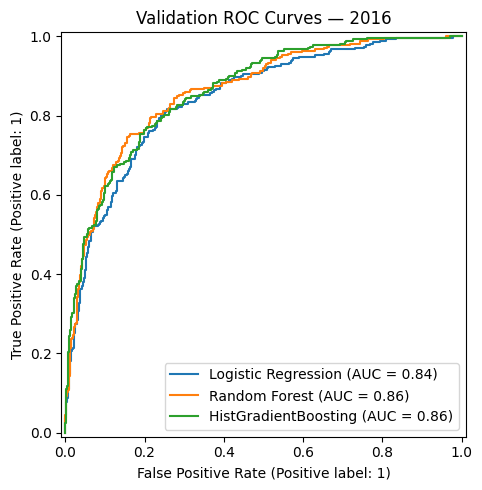

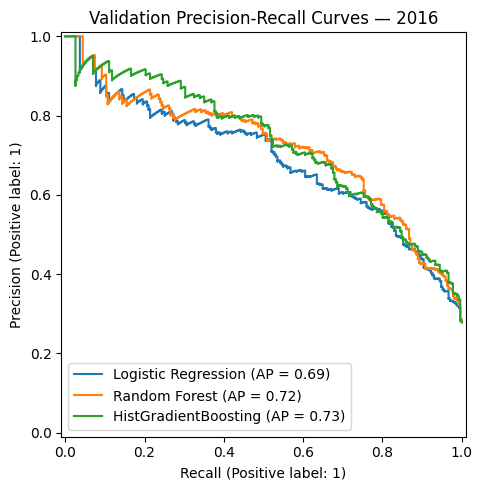

In [16]:
# Validation ROC and Precision-Recall curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, search in searches.items():
    RocCurveDisplay.from_estimator(search.best_estimator_, X_val, y_val, name=name, ax=ax)
ax.set_title("Validation ROC Curves — 2016")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name, search in searches.items():
    PrecisionRecallDisplay.from_estimator(search.best_estimator_, X_val, y_val, name=name, ax=ax)
ax.set_title("Validation Precision-Recall Curves — 2016")
plt.tight_layout()
plt.show()

## 9. Probability calibration

For decision analytics, a probability such as 0.70 is useful only if it has an interpretable relationship to event frequency. Calibration curves compare predicted probabilities with observed rainfall rates.

The calibration analysis is descriptive: model selection remains based on validation Average Precision and final performance is assessed on the held-out 2017 test set.

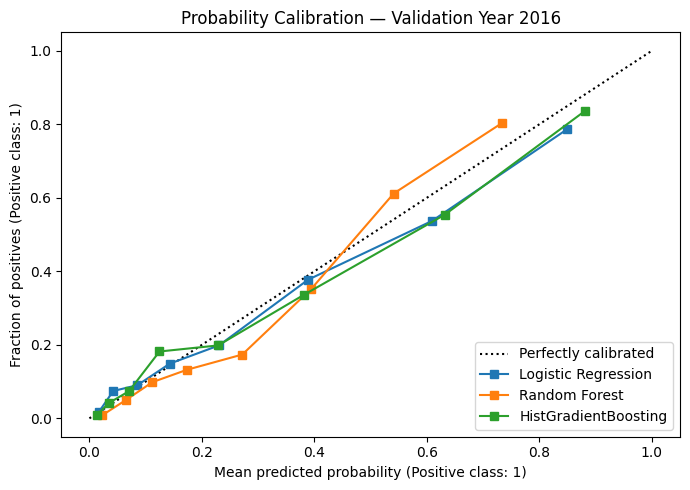

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, search in searches.items():
    CalibrationDisplay.from_estimator(
        search.best_estimator_, X_val, y_val, n_bins=8, strategy="quantile", name=name, ax=ax
    )
ax.set_title("Probability Calibration — Validation Year 2016")
plt.tight_layout()
plt.show()

## 10. Model selection and validation-only threshold optimization

The default 0.50 threshold is not necessarily optimal when false negatives and false positives have different operational costs.

The selected model is the one with the highest validation **Average Precision**. Its probability threshold is then chosen using **validation data only**.

Two decision rules are shown:
- threshold maximizing rainfall-class F1;
- threshold minimizing a simple illustrative loss where a missed rainy day (false negative) costs twice as much as a false alarm (false positive).

The final test set is not used in this decision.

Selected model: HistGradientBoosting
F1-maximizing validation threshold: 0.438
Illustrative-cost-minimizing threshold: 0.438


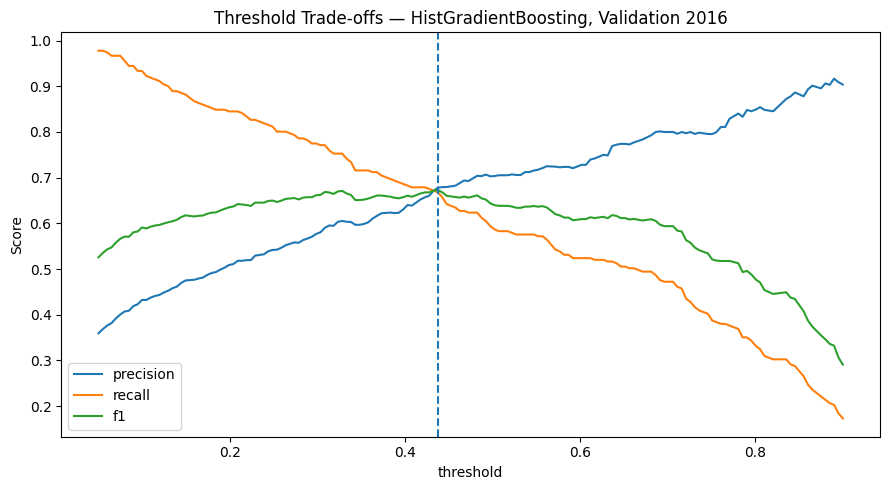

In [18]:
best_model_name = validation_results.iloc[0]["Model"]
best_search = searches[best_model_name]
val_prob = best_search.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.90, 172)
threshold_rows = []

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "illustrative_cost": fp + 2 * fn
    })

threshold_df = pd.DataFrame(threshold_rows)

f1_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]
cost_threshold = threshold_df.loc[threshold_df["illustrative_cost"].idxmin(), "threshold"]

print("Selected model:", best_model_name)
print(f"F1-maximizing validation threshold: {f1_threshold:.3f}")
print(f"Illustrative-cost-minimizing threshold: {cost_threshold:.3f}")

ax = threshold_df.plot(x="threshold", y=["precision", "recall", "f1"], figsize=(9, 5))
ax.axvline(f1_threshold, linestyle="--", label="F1-optimal threshold")
ax.set_title(f"Threshold Trade-offs — {best_model_name}, Validation 2016")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

For the primary final evaluation, the **F1-maximizing validation threshold** is used because it balances rainfall precision and recall without requiring a domain-specific monetary cost model. The illustrative cost analysis is retained to demonstrate how the same probabilistic model can support alternative decision objectives.

## 11. Final refit and untouched 2017 test

After model family, hyperparameters, and threshold are fixed, the selected pipeline is refit using all observations through the end of 2016. The 2017 observations are then used exactly once for final evaluation.

In [19]:
# Refit the selected best-parameter pipeline on development + validation data
X_train_final = pd.concat([X_dev, X_val]).sort_index()
y_train_final = pd.concat([y_dev, y_val]).sort_index()

final_model = clone(best_search.best_estimator_)
final_model.fit(X_train_final, y_train_final)

test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred_default = (test_prob >= 0.50).astype(int)
test_pred_selected = (test_prob >= f1_threshold).astype(int)

final_results = pd.DataFrame([
    metric_row(f"{best_model_name} — default 0.50", y_test, test_prob, 0.50),
    metric_row(f"{best_model_name} — validation-selected", y_test, test_prob, f1_threshold)
])

display(final_results.round(3))

,Model,Threshold,Accuracy,Balanced accuracy,Rain precision,Rain recall,Rain F1,ROC-AUC,Average precision,Brier score
0,HistGradientBoosting — default 0.50,0.500,0.848,0.643,0.705,0.316,0.437,0.841,0.611,0.109
1,HistGradientBoosting — validation-selected,0.438,0.857,0.676,0.717,0.388,0.503,0.841,0.611,0.109


Classification report — final 2017 test, validation-selected threshold
              precision    recall  f1-score   support

     No rain      0.873     0.965     0.917       428
        Rain      0.717     0.388     0.503        98

    accuracy                          0.857       526
   macro avg      0.795     0.676     0.710       526
weighted avg      0.844     0.857     0.840       526



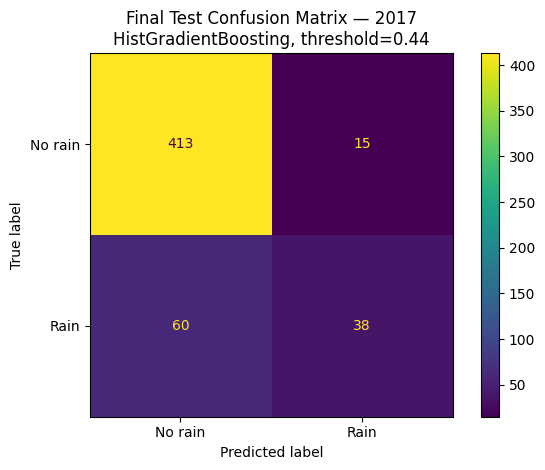

In [20]:
print("Classification report — final 2017 test, validation-selected threshold")
print(classification_report(y_test, test_pred_selected, target_names=["No rain", "Rain"], digits=3))

cm = confusion_matrix(y_test, test_pred_selected)
disp = ConfusionMatrixDisplay(cm, display_labels=["No rain", "Rain"])
disp.plot()
plt.title(f"Final Test Confusion Matrix — 2017\n{best_model_name}, threshold={f1_threshold:.2f}")
plt.tight_layout()
plt.show()

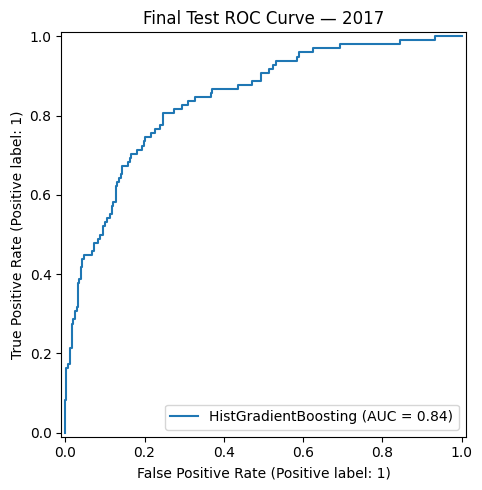

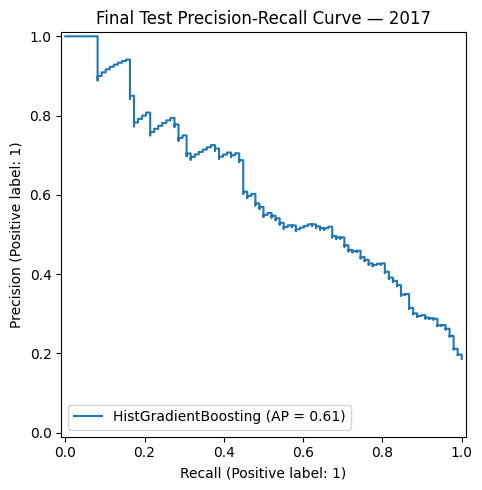

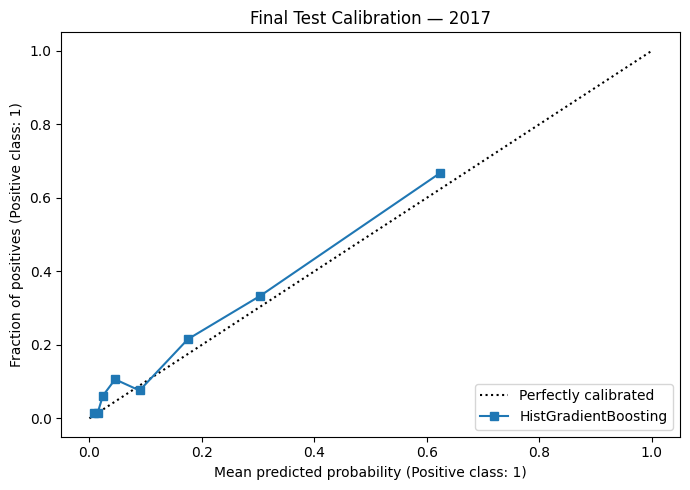

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, test_prob, name=best_model_name, ax=ax)
ax.set_title("Final Test ROC Curve — 2017")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, test_prob, name=best_model_name, ax=ax)
ax.set_title("Final Test Precision-Recall Curve — 2017")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(
    y_test, test_prob, n_bins=8, strategy="quantile", name=best_model_name, ax=ax
)
ax.set_title("Final Test Calibration — 2017")
plt.tight_layout()
plt.show()

## 12. Model-agnostic feature importance on held-out data

The original notebook used impurity-based Random Forest feature importance. Tree impurity importance can be biased toward some feature types and is model-specific.

In this extension notebook, I use **permutation importance** on the untouched 2017 test set with Average Precision as the scoring function. A feature is considered important when shuffling that raw input column reduces held-out predictive performance.

Permutation importance is still **predictive**, not causal, and correlated variables can share or mask importance.

,feature,importance_mean,importance_std
15,Pressure3pm,0.1487,0.0164
13,Humidity3pm,0.1111,0.0220
7,WindGustSpeed,0.0896,0.0105
5,Sunshine,0.0694,0.0182
17,Cloud3pm,0.0195,0.0062
14,Pressure9am,0.0178,0.0130
2,MaxTemp,0.0101,0.0038
1,MinTemp,0.0058,0.0026
8,WindDir9am,0.0054,0.0056
23,DayOfYearCos,0.0050,0.0043


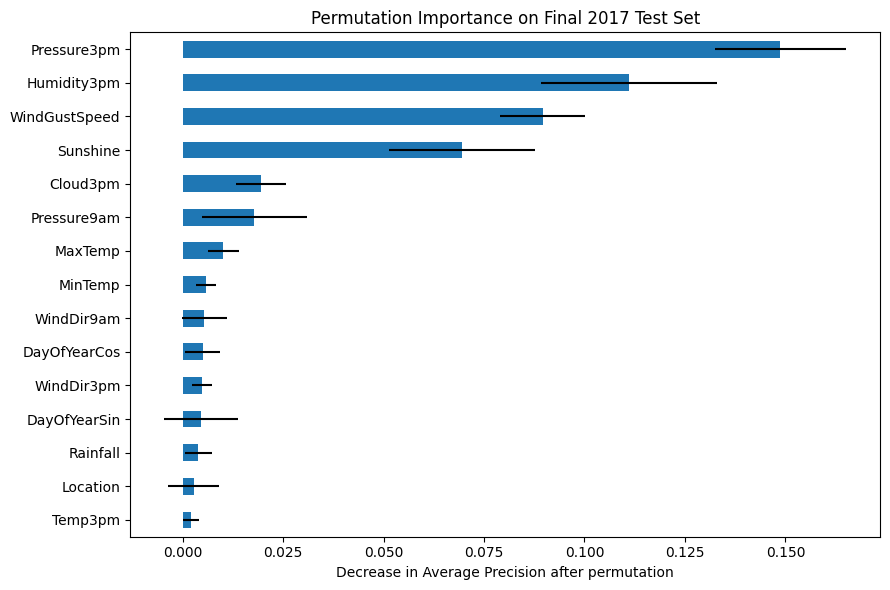

In [22]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(15).round(4))

top_perm = perm_df.head(15).sort_values("importance_mean")
ax = top_perm.plot(
    x="feature", y="importance_mean", xerr="importance_std",
    kind="barh", figsize=(9, 6), legend=False
)
ax.set_title("Permutation Importance on Final 2017 Test Set")
ax.set_xlabel("Decrease in Average Precision after permutation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 13. Error analysis by season and station

Aggregate performance can conceal operationally important heterogeneity. The same final predictions are therefore decomposed by:
- weather station;
- Australian season.

This does **not** retune the model by subgroup. It is a diagnostic analysis of where the selected model performs better or worse.

In [23]:
test_meta = model_df.loc[test_mask, ["Date", "Location", "Season"]].copy()
test_meta["y_true"] = y_test.values
test_meta["prob"] = test_prob
test_meta["pred"] = test_pred_selected

def grouped_error_table(frame, group):
    rows = []
    for level, g in frame.groupby(group):
        if g["y_true"].nunique() < 2:
            roc = np.nan
            ap = np.nan
        else:
            roc = roc_auc_score(g["y_true"], g["prob"])
            ap = average_precision_score(g["y_true"], g["prob"])
        rows.append({
            group: level,
            "n": len(g),
            "rain_rate": g["y_true"].mean(),
            "accuracy": accuracy_score(g["y_true"], g["pred"]),
            "balanced_accuracy": balanced_accuracy_score(g["y_true"], g["pred"]),
            "rain_recall": recall_score(g["y_true"], g["pred"], zero_division=0),
            "rain_f1": f1_score(g["y_true"], g["pred"], zero_division=0),
            "roc_auc": roc,
            "average_precision": ap
        })
    return pd.DataFrame(rows)

station_errors = grouped_error_table(test_meta, "Location")
season_errors = grouped_error_table(test_meta, "Season")

print("Performance by station")
display(station_errors.round(3))

print("Performance by season")
display(season_errors.round(3))

Performance by station


,Location,n,rain_rate,accuracy,balanced_accuracy,rain_recall,rain_f1,roc_auc,average_precision
0,Melbourne,176,0.193,0.852,0.674,0.382,0.50,0.815,0.603
1,MelbourneAirport,176,0.176,0.864,0.676,0.387,0.50,0.867,0.642
2,Watsonia,174,0.190,0.856,0.679,0.394,0.51,0.843,0.609


Performance by season


,Season,n,rain_rate,accuracy,balanced_accuracy,rain_recall,rain_f1,roc_auc,average_precision
0,Autumn,274,0.230,0.839,0.695,0.429,0.551,0.853,0.682
1,Summer,177,0.136,0.893,0.710,0.458,0.537,0.803,0.542
2,Winter,75,0.147,0.840,0.492,0.000,0.000,0.822,0.439


Spring is absent from the seasonal error table because the final test period ends on June 25, 2017 and therefore contains no spring(September to November) observations.

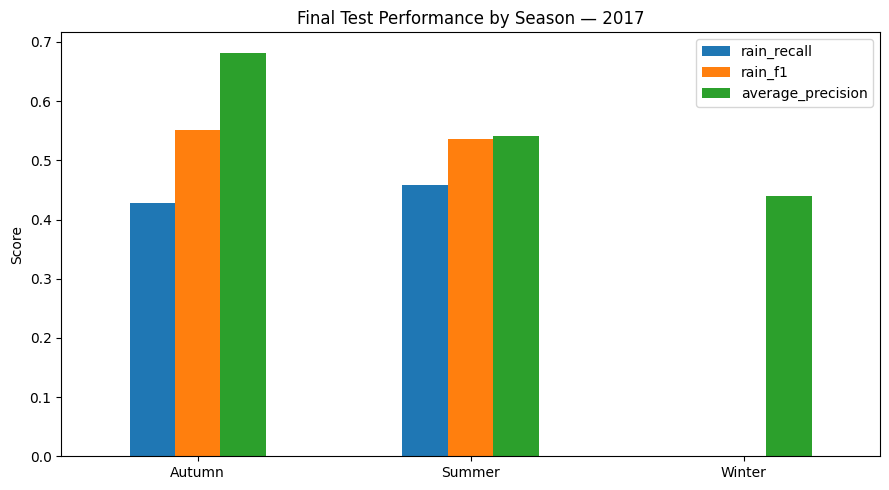

In [24]:
ax = season_errors.set_index("Season")[["rain_recall", "rain_f1", "average_precision"]].plot(
    kind="bar", figsize=(9, 5)
)
ax.set_title("Final Test Performance by Season — 2017")
ax.set_ylabel("Score")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Again, spring is absent from the graph because the final test period ends on June 25, 2017 and therefore contains no spring(September to November) observations.

## 14. Station-holdout robustness check

The three Melbourne-area stations are geographically related, so row-level observations are not fully independent in a spatial sense. As a robustness check, the selected model specification is trained on **two stations through 2016** and tested on the **held-out third station in 2017**.

This is intentionally harder than the primary task. It asks whether the learned relationship generalizes to a nearby station not used for fitting.

In [25]:
station_holdout_rows = []

for heldout in metro_locations:
    train_mask = (years <= 2016) & (model_df["Location"] != heldout)
    station_test_mask = (years == 2017) & (model_df["Location"] == heldout)

    if station_test_mask.sum() == 0:
        continue

    station_model = clone(best_search.best_estimator_)
    station_model.fit(X.loc[train_mask], y.loc[train_mask])

    station_prob = station_model.predict_proba(X.loc[station_test_mask])[:, 1]
    station_pred = (station_prob >= f1_threshold).astype(int)
    y_station = y.loc[station_test_mask]

    station_holdout_rows.append({
        "Held-out station": heldout,
        "n": len(y_station),
        "Rain rate": y_station.mean(),
        "Accuracy": accuracy_score(y_station, station_pred),
        "Balanced accuracy": balanced_accuracy_score(y_station, station_pred),
        "Rain recall": recall_score(y_station, station_pred, zero_division=0),
        "Rain F1": f1_score(y_station, station_pred, zero_division=0),
        "Average precision": average_precision_score(y_station, station_prob)
            if y_station.nunique() > 1 else np.nan
    })

station_holdout_results = pd.DataFrame(station_holdout_rows)
station_holdout_results.round(3)

,Held-out station,n,Rain rate,Accuracy,Balanced accuracy,Rain recall,Rain F1,Average precision
0,Melbourne,176,0.193,0.847,0.659,0.353,0.471,0.608
1,MelbourneAirport,176,0.176,0.858,0.711,0.484,0.545,0.632
2,Watsonia,174,0.190,0.828,0.650,0.364,0.444,0.554


## 15. Interpretation of Empirical Results

The preceding analyses provide several complementary perspectives on predictive performance. Rather than interpreting the selected model through accuracy alone, this section evaluates whether the model improves on a naïve benchmark, detects the minority rainfall class, preserves ranking performance over time, produces useful probabilities, and generalizes across temporal and spatial subgroups.

### 15.1 Baseline Gain

The selected Histogram Gradient Boosting model provides meaningful predictive information beyond a naïve majority-class strategy. In the final 2017 test period, rainfall prevalence was approximately **18.6%**, meaning that a classifier predicting “No Rain” for every observation would achieve approximately **81.4% accuracy** while detecting **none of the rainy days**.

At the validation-selected threshold of **0.438**, the final model achieved **85.7% accuracy**, **67.6% balanced accuracy**, **0.841 ROC-AUC**, and **0.611 Average Precision**. Thus, the improvement over the naïve benchmark is not simply the 4.3-percentage-point increase in accuracy. More importantly, the model identifies a subset of rainfall events while retaining substantial discrimination between rainy and non-rainy observations.

### 15.2 Minority-Class Performance

Rainfall is the minority class, so rainfall-specific precision, recall, and F1 are more informative than overall accuracy alone.

On the final 2017 test period, the selected threshold produced:

* **Rainfall precision:** 0.717
* **Rainfall recall:** 0.388
* **Rainfall F1:** 0.503

The corresponding confusion matrix contains approximately **413 true negatives, 15 false positives, 60 false negatives, and 38 true positives**.

Therefore, when the model predicts rainfall, approximately **71.7% of those predictions are correct**. However, it detects only **38.8% of the rainfall events that actually occurred**. The model is consequently relatively conservative: it avoids many false rainfall alarms, but this comes at the cost of missing a substantial proportion of rainy days.

This distinction is operationally important because the preferred precision–recall trade-off depends on the relative cost of false positives and false negatives.

### 15.3 Ranking Quality

Average Precision should be interpreted relative to the prevalence of the positive class. Rainfall prevalence in the final test period was approximately **0.186**, whereas the selected model achieved **Average Precision = 0.611**.

The large difference between these values indicates that the model provides substantial ranking information beyond the underlying event frequency. In other words, observations assigned higher rainfall probabilities are meaningfully enriched for actual rainfall events.

The final **ROC-AUC of 0.841** provides consistent evidence of discrimination. This distinction is particularly important because ranking quality can remain useful even when a fixed classification threshold produces relatively low rainfall recall.

### 15.4 Temporal Generalization

Performance deteriorated between the 2016 validation period and the untouched 2017 test period.

For Histogram Gradient Boosting, the 2016 validation results at the default 0.50 threshold included:

* **ROC-AUC:** 0.861
* **Average Precision:** 0.728
* **Rainfall recall:** 0.587
* **Rainfall F1:** 0.640

On the final 2017 period, ROC-AUC remained relatively strong at **0.841**, while Average Precision declined to **0.611**. At the validation-selected threshold of 0.438, rainfall recall fell to **0.388** and rainfall F1 to **0.503**.

The decline is substantively important. It suggests that the model retained considerable ability to rank higher-risk observations, but the relationship between predicted probabilities and the classification threshold was less stable over time.

This result demonstrates why temporally realistic validation is central to forecasting applications: performance estimated on one historical period should not automatically be assumed to persist in a later period.

### 15.5 Probability Calibration

The final model achieved a **Brier score of 0.109**, providing evidence that the predicted probabilities contain useful probabilistic information. The calibration analysis should nevertheless be interpreted jointly with the observed temporal deterioration.

The distinction between discrimination and calibration is important. A model can rank rainy observations above dry observations reasonably well while its predicted probability levels are not perfectly aligned with subsequent event frequencies.

The persistence of relatively strong ROC-AUC alongside weaker threshold-based rainfall recall in 2017 suggests that probability ranking remained more stable than the operational classification rule. In a deployed forecasting system, this would motivate ongoing calibration monitoring and potentially periodic recalibration or threshold revision.

### 15.6 Error Heterogeneity

Performance is not uniform across all observations.

Across stations in the final test period, rainfall F1 was approximately **0.50–0.51**, with ROC-AUC ranging from approximately **0.815 to 0.867** and Average Precision from approximately **0.603 to 0.642**. This indicates reasonably similar performance across Melbourne, Melbourne Airport, and Watsonia within the primary temporal test.

Seasonal results reveal greater heterogeneity. The final test period covers only **January through June 25, 2017**, so Spring is not represented and Winter contains only **75 observations**.

Most notably, Winter rainfall recall and F1 were both **0.000**. This does not mean that the model contained no information during Winter: Winter ROC-AUC remained approximately **0.822** and Average Precision approximately **0.439**. Rather, none of the actual Winter rainfall observations crossed the globally selected 0.438 decision threshold.

This combination of non-zero ranking performance and zero threshold-based recall illustrates how aggregate metrics can conceal subgroup-specific decision failures. Because the Winter subset is small, however, this result should be interpreted cautiously rather than treated as evidence of a general seasonal pattern.

### 15.7 Feature Reliance

Held-out permutation importance shows that the model's final-test predictive performance relies most strongly on several meteorologically meaningful variables.

The largest reductions in Average Precision occurred when permuting:

1. **Pressure3pm:** 0.1487
2. **Humidity3pm:** 0.1111
3. **WindGustSpeed:** 0.0896
4. **Sunshine:** 0.0694
5. **Cloud3pm:** 0.0195
6. **Pressure9am:** 0.0178
7. **MaxTemp:** 0.0101

Pressure3pm therefore produced the largest deterioration in held-out Average Precision when its information was disrupted, followed by Humidity3pm, WindGustSpeed, and Sunshine.

These values should be interpreted as **predictive reliance rather than causal effects**. Correlation among meteorological predictors means that importance can be shared across variables, and permutation importance does not establish that changing a predictor would cause rainfall probability to change.

### 15.8 Spatial Robustness

The station-holdout experiment provides a more demanding test of spatial generalization because each model is evaluated on a station excluded from its training data.

Average Precision was approximately:

* **Melbourne held out:** 0.608
* **Melbourne Airport held out:** 0.632
* **Watsonia held out:** 0.554

Rainfall F1 ranged from approximately **0.444 to 0.545** across these experiments.

The model therefore retains meaningful predictive information when transferred to an unseen Melbourne-area station, but performance is not invariant across locations. Watsonia produced the weakest held-out Average Precision, indicating that geographic transfer remains imperfect even among relatively nearby stations.

These results support the use of station-holdout analysis as a robustness check rather than assuming that observations from nearby locations are interchangeable.

### 15.9 Overall Interpretation

Taken together, the results support a more nuanced conclusion than “the model is 85.7% accurate.”

The selected Histogram Gradient Boosting model demonstrates **meaningful predictive signal**, with final-test ROC-AUC of **0.841** and Average Precision of **0.611**, substantially above the 18.6% rainfall prevalence. It also produces relatively precise positive predictions, with rainfall precision of **71.7%**.

At the same time, the model detects only **38.8% of actual rainfall events** at the validation-selected threshold, and performance deteriorates between the 2016 validation period and the 2017 test period. Seasonal and station-holdout analyses further show that predictive performance is not completely stable across time and location.

The study shows that meteorological observations contain substantial information for next-day rainfall prediction, while **temporal generalization, decision-threshold stability, minority-class detection, and subgroup heterogeneity remain important limitations**.

From a broader predictive-analytics perspective, these findings demonstrate why model evaluation should extend beyond aggregate accuracy to include temporal validation, class-specific performance, probability quality, error costs, and robustness across relevant subgroups.


## 16. Methodological limitations

Even after the redesign, important limitations remain:

- **Observational dataset:** predictive associations are not causal relationships.
- **Measurement timing:** some weather variables describe conditions over a daily observation window. The intended deployment time must match the availability of those measurements.
- **Geographic scope:** the primary model is a Melbourne-metro model; conclusions should not be generalized automatically to all Australian climates.
- **Spatial dependence:** nearby stations can experience the same weather system. The station-holdout analysis partially tests this issue but does not model spatial correlation explicitly.
- **Temporal drift:** climate and instrumentation can change over time. A production model would require periodic monitoring and retraining.
- **Threshold objective:** the F1-selected threshold is a statistical compromise. A real decision system should use domain-specific costs for missed rainfall and false alarms.
- **Probability calibration:** calibration should be monitored on future data and may warrant dedicated cross-validated calibration if probability quality becomes a primary deployment requirement.
- **Missingness mechanism:** median/mode imputation is transparent and leakage-safe but does not prove that missingness is ignorable.

These limitations define a credible path for future research rather than weaknesses to hide.

## 17. Relationship to the original IBM Machine Learning Certificate project

The original exercise notebook established the following workflow:

`weatherAUS → complete-case deletion → Melbourne-area restriction → season feature → randomized stratified split → ColumnTransformer → Pipeline → GridSearchCV → Random Forest → Logistic Regression → classification metrics → feature importance`

Saved results in the original notebook included:

| Original result | Saved value |
|---|---:|
| Raw rows | 145,460 |
| Complete-case rows | 56,420 |
| Melbourne-area complete cases | 7,557 |
| Rain observations | 1,791 |
| No-rain observations | 5,766 |
| Majority-class baseline accuracy | 76.31% |
| Random Forest test accuracy | ~84% |
| Random Forest rain recall | ~51.1% |
| Logistic Regression test accuracy | ~83% |
| Logistic Regression rain recall | ~50.8% |

Those values are retained here as **historical provenance**, not as results from the redesigned temporal experiment.

### What changed in this portfolio version

| Original certificate workflow | Portfolio redevelopment |
|---|---|
| Complete-case deletion | Pipeline-contained numerical/categorical imputation |
| Randomized stratified split | Chronological development / validation / test |
| Stratified K-fold CV | Expanding-year temporal CV |
| Accuracy optimization | Average Precision optimization + multi-metric evaluation |
| RF vs Logistic Regression | Baseline + Logistic + RF + Gradient Boosting |
| Default 0.50 threshold | Validation-only threshold analysis |
| Tree impurity importance | Held-out permutation importance |
| Aggregate evaluation | Season, station, calibration, and station-holdout diagnostics |
| “today” relabeling | Explicit day \(t\) → day \(t+1\) forecasting horizon |

## 18. Portfolio conclusion

Using a chronological forecasting design, **Histogram Gradient Boosting** was selected as the preferred model after expanding-window tuning on pre-2016 observations and model comparison on the 2016 validation period. On validation data, the model achieved an **Average Precision of 0.728**, **ROC-AUC of 0.861**, **rainfall recall of 0.587**, and **rainfall F1 of 0.640** at the default 0.50 threshold. A validation-only threshold analysis selected a probability cutoff of **0.438**, which was then fixed before the final test.

On the untouched **2017 test period (526 observations)**, rainfall prevalence fell to **18.6%**, compared with **27.9% in 2016**, providing a materially different out-of-sample environment. At the validation-selected threshold, the final model achieved **85.7% accuracy**, **0.676 balanced accuracy**, **0.717 rainfall precision**, **0.388 rainfall recall**, **0.503 rainfall F1**, **0.841 ROC-AUC**, and **0.611 Average Precision**. The corresponding majority-class accuracy for 2017 was approximately **81.4%**, so the gain in overall accuracy was modest; the much larger gap between Average Precision (0.611) and the 2017 rainfall prevalence (0.186) provides stronger evidence that the model learned useful ranking information beyond the naïve baseline.

The temporal holdout also revealed an important limitation that a randomized split could obscure: **rainfall-event sensitivity deteriorated substantially from validation to final test**, even though ROC-AUC remained relatively strong. This suggests that the model ranked risk reasonably well but that the mapping from predicted probability to the optimal classification threshold was less stable across years. In a deployment context, this would justify ongoing calibration and threshold monitoring rather than treating a single historical cutoff as permanent.

Permutation importance on the final test period identified **Pressure3pm, Humidity3pm, WindGustSpeed, and Sunshine** as the strongest contributors to held-out Average Precision. These results are predictive rather than causal and should be interpreted as measures of model reliance.

Subgroup diagnostics showed relatively similar aggregate performance across the three Melbourne-area stations, while seasonal performance was more uneven. In the small 2017 winter subset, the model failed to identify any of the observed rainy days, although the subgroup contained only 75 observations and should therefore be interpreted cautiously. The station-holdout robustness check also showed that transfer to an unseen station was possible but weaker for some locations, with Average Precision ranging from approximately **0.554 to 0.632**.

Overall, the study demonstrates that next-day rainfall in metropolitan Melbourne contains substantial predictive signal, but it also shows why **temporal validation, class-specific evaluation, calibration, and decision-threshold analysis are essential**. The main contribution of this portfolio redevelopment is therefore not a claim of exceptionally high forecasting accuracy; it is a more defensible machine-learning workflow that distinguishes model fitting from realistic out-of-sample evaluation and communicates where predictive performance remains limited.

## 19. References

1. Australian Bureau of Meteorology. *About rainfall data*. https://www.bom.gov.au/climate/cdo/about/about-rain-data.shtml  
2. Australian Bureau of Meteorology. *Climate Data Online — rainfall definitions*. https://www.bom.gov.au/climate/cdo/about/definitionsrain.shtml  
3. scikit-learn developers. *TimeSeriesSplit*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html  
4. scikit-learn developers. *Permutation feature importance*. https://scikit-learn.org/stable/modules/permutation_importance.html  
5. scikit-learn developers. *Probability calibration*. https://scikit-learn.org/stable/modules/calibration.html  
6. Breiman, L. (2001). Random Forests. *Machine Learning*, 45, 5–32.  
7. Original portfolio precursor: IBM Machine Learning Certificate rainfall-classification project using the `weatherAUS` dataset.

---


## Appendix A. Original notebook metadata

The source notebook supplied for redevelopment contained **78 cells**: **30 code cells** and **48 Markdown cells**. Its strongest reusable components—scikit-learn pipelines, heterogeneous preprocessing, GridSearchCV, Random Forest, Logistic Regression, confusion matrices, classification reports, and feature-importance extraction—were retained conceptually while the **validation and evaluation design** was rebuilt.